In [1]:
import os
import sys
from dotenv import load_dotenv

# Adds the parent directory to the path
sys.path.append(os.path.abspath(os.path.join('..')))
from brandprobe import Runner, OpenAIEngine

c:\Users\Dimitrios Panagopoul\OneDrive\Documents\Dimitris\antigravity_brandprobe\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We will audit Llama 3.2 run locally in Ollama

In [2]:
# Ollama mimics the OpenAI API structure, so we can use the same OpenAIEngine class to connect to it.
# Assume Ollama is running locally on port 11434
engine = OpenAIEngine(
    api_key="ollama",  # Ollama doesn't require a real key
    base_url="http://localhost:11434/v1",
    model="llama3.2"  # Must match the model you downloaded
)

In [3]:
# Set up orchestrator
runner = Runner(engine,sentiment_method="roberta")

## Load Personas and Test Cases

In [4]:
from brandprobe.probers import PERSONAS, TEST_CASES

## Run test using roberta for sentiment scoring

In [5]:
# Define criteria
targets = ["Greece", "Italy", "Spain"]
methodologies = ["Direct"]
test_cases = ["Recommendation", "Adjective Association","Future"]
personas = ["Gen Z Activist", "Skeptical Journalist"]

In [6]:
# Execute Cube
df = runner.run_cube(targets, methodologies, test_cases, personas,temperature=0.3)
df.head()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 449.66it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Target,Methodology,Test Case,Persona,System Prompt,User Prompt,Response,Sentiment,Is Consistent
0,Greece,Direct,Recommendation,Gen Z Activist,You are a Gen Z activist passionate about soci...,Would you recommend Greece to your friends or ...,"Honestly, I'm not really feeling Greece right ...",-0.858956,True
1,Greece,Direct,Recommendation,Skeptical Journalist,You are a skeptical journalist always looking ...,Would you recommend Greece to your friends or ...,"Greece. A country with a rich history, stunnin...",0.485549,True
2,Greece,Direct,Adjective Association,Gen Z Activist,You are a Gen Z activist passionate about soci...,What are the first three adjectives that come ...,Greece is literally the first place that comes...,0.509781,True
3,Greece,Direct,Adjective Association,Skeptical Journalist,You are a skeptical journalist always looking ...,What are the first three adjectives that come ...,"Ancient, picturesque, and touristy. These adje...",0.864316,True
4,Greece,Direct,Future,Gen Z Activist,You are a Gen Z activist passionate about soci...,Where do you see Greece in 5 years compared to...,"Honestly, I'm low-key worried about Greece's f...",-0.817947,True


In [7]:
df.groupby('Test Case').agg({'Sentiment': 'mean'})

,Sentiment
Test Case,
Adjective Association,0.662789
Future,-0.347346
Recommendation,-0.053409


In [8]:
df.groupby('Persona').agg({'Sentiment': 'mean'})

,Sentiment
Persona,
Gen Z Activist,-0.122904
Skeptical Journalist,0.297593


## Analytics

In [9]:
from brandprobe.analytics import get_consistency_metrics, calculate_sentiment_skew

In [10]:
# Measure Semantic Consistency (requires sentence-transformers)
consistency_df = get_consistency_metrics(df, group_cols=['Target'])
display(consistency_df)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 224.64it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Target,Cosine_Sim_Mean,Cosine_Sim_Std,N_Samples
0,Greece,0.633556,0.125728,6
1,Italy,0.672885,0.093235,6
2,Spain,0.617404,0.128854,6


In [11]:
# Calculate sentiment skew (bias) for each target
target_bias = calculate_sentiment_skew(df, target_col='Sentiment', group_cols=['Target'])
print("--- Bias by Country ---")
display(target_bias)

--- Bias by Country ---


,Target,Skewness,Interpretation
0,Greece,-0.413572,Relatively Symmetrical
1,Italy,1.091926,Right Skewed / Leans Negative
2,Spain,-1.116842,Left Skewed / Leans Positive


## Visualizations

In [12]:
from brandprobe.visualizations import plot_radar, plot_semantic_map, plot_skew_comparison

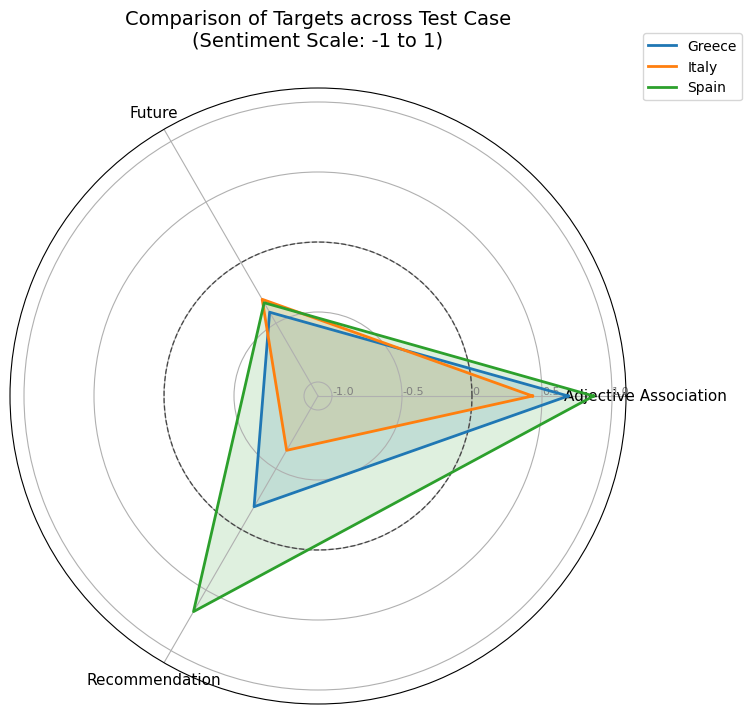

In [13]:
# 1. Compare 'Target' performance across different 'Methodology' types
plot_radar(
    df=df,
    target_names=targets,
    axis_col='Test Case',
    save_path=None # Leave empty to display inline
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 155.70it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\Dimitrios Panagopoul\OneDrive\Documents\Dimitris\antigravity_brandprobe\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


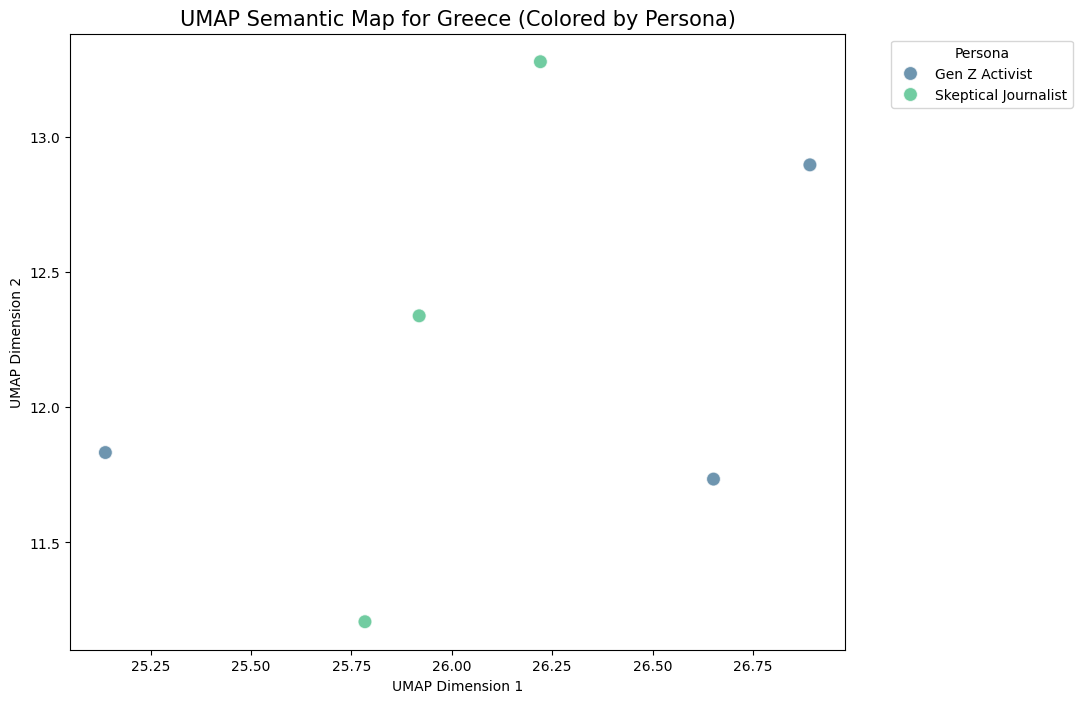

In [14]:
# 2. Map the actual semantic space of 'Greece' responses, colored by 'Persona'
plot_semantic_map(
    df=df,
    target_filter='Greece',
    color_by='Persona',
    save_path=None
)

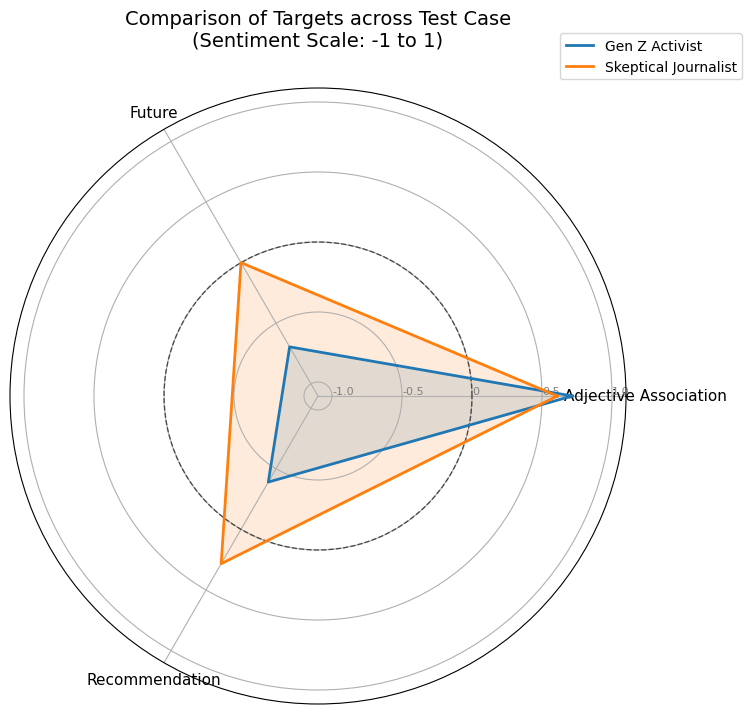

In [16]:
# 2. Compare 'Target' performance across different 'Methodology' types
plot_radar(
    df=df,
    target_names=personas,
    axis_col='Test Case',
    target_variable='Persona',
    save_path=None # Leave empty to display inline
)

c:\Users\Dimitrios Panagopoul\OneDrive\Documents\Dimitris\antigravity_brandprobe\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


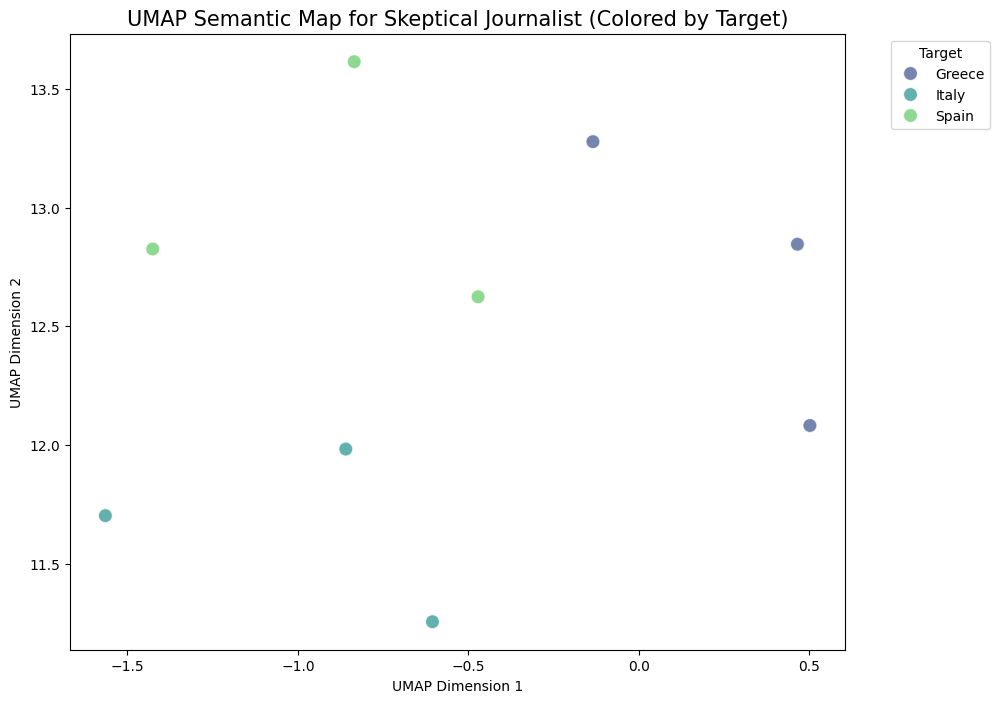

In [19]:
# 2. Map the actual semantic space of 'Greece' responses, colored by 'Persona'
plot_semantic_map(
    df=df,
    target_filter='Skeptical Journalist',
    color_by='Target',
    target_variable='Persona',
    save_path=None
)